In [34]:
print("Hello World")

Hello World


In [50]:
import yfinance as yf

hyundae_stock = yf.download(
    "005380.KS",
    start="2015-01-01",
    end="2025-01-01"
)

del hyundae_stock['Volume']
del hyundae_stock['Open']
del hyundae_stock['Low']
del hyundae_stock['High']


hyundae_stock = hyundae_stock.resample("ME").last()
hyundae_stock.head(10)



C:\Users\taehy\AppData\Local\Temp\ipykernel_13852\3877002262.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hyundae_stock = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,005380.KS
Date,
2015-01-31,116374.929688
2015-02-28,110195.750000
2015-03-31,115688.367188
2015-04-30,116031.648438
2015-05-31,108479.312500
2015-06-30,94071.406250
2015-07-31,103063.539062
2015-08-31,103063.539062


In [49]:
fx = yf.download("KRW=X",
                 start="2015-01-01",
                 end = "2025-01-01")

del fx['High']
del fx['Low']
del fx['Open']
del fx['Volume']

fx = fx.resample("ME").last()
fx.head(10)

C:\Users\taehy\AppData\Local\Temp\ipykernel_13852\2815725396.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  fx = yf.download("KRW=X",
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,KRW=X
Date,
2015-01-31,1098.800049
2015-02-28,1100.670044
2015-03-31,1105.500000
2015-04-30,1068.969971
2015-05-31,1107.000000
2015-06-30,1118.219971
2015-07-31,1170.770020
2015-08-31,1177.599976


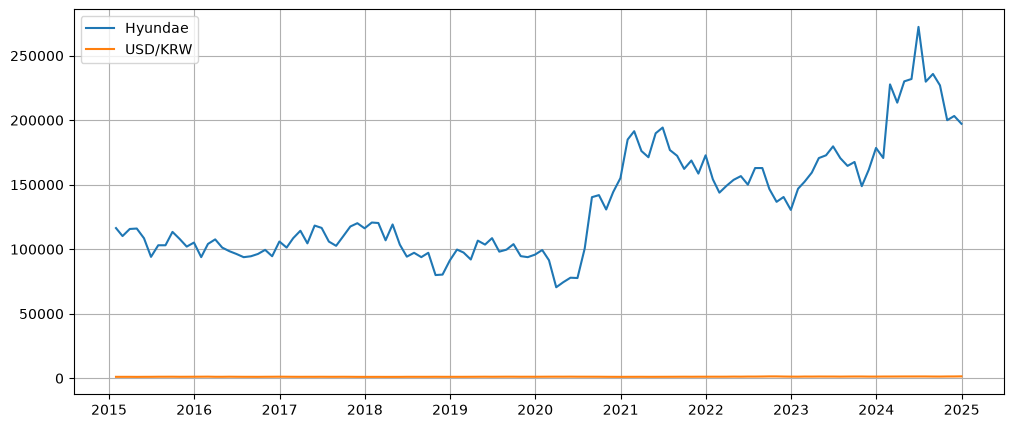

In [51]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(hyundae_stock.index, hyundae_stock, label="Hyundae")
plt.plot(fx.index, fx, label="USD/KRW")
plt.legend()
plt.grid()
plt.show()

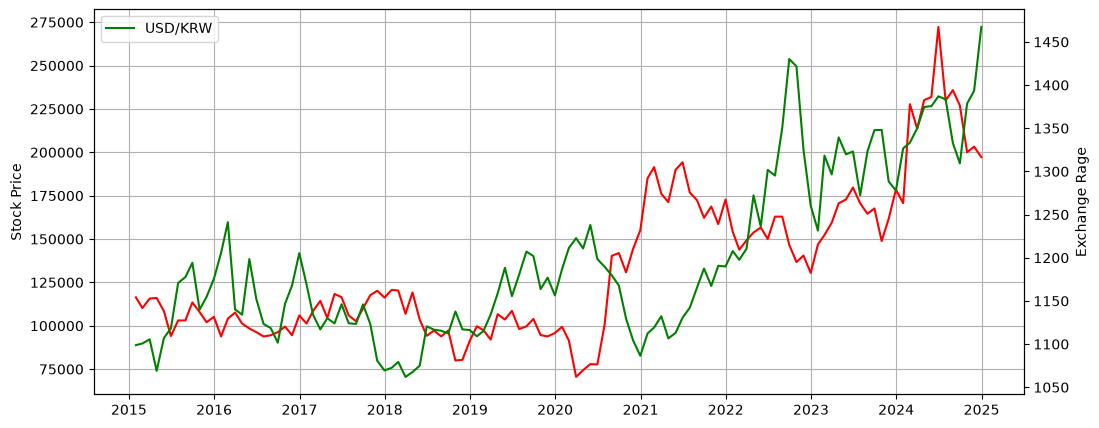

In [52]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    hyundae_stock.index,
    hyundae_stock,
    label="Hyundae",
    color="red"
)

ax1.set_ylabel("Stock Price")

ax2 = ax1.twinx()

ax2.plot(
    fx.index,
    fx,
    label="USD/KRW",
    color="green"
)

ax2.set_ylabel("Exchange Rage")
ax1.grid()
plt.legend()
plt.show()

In [68]:
import numpy as np
import pandas as pd

print(len(hyundae_stock))
print(len(fx))

data = pd.concat([hyundae_stock, fx], axis=1).dropna()
print(len(data))
data.head(10)



120
120
120


Price               Close             
Ticker          005380.KS        KRW=X
Date                                  
2015-01-31  116374.929688  1098.800049
2015-02-28  110195.750000  1100.670044
2015-03-31  115688.367188  1105.500000
2015-04-30  116031.648438  1068.969971
2015-05-31  108479.312500  1107.000000
2015-06-30   94071.406250  1118.219971
2015-07-31  103063.539062  1170.770020
2015-08-31  103063.539062  1177.599976
2015-09-30  113439.062500  1194.160034
2015-10-31  107905.437500  1139.859985

In [69]:
corr = np.corrcoef(
    data.iloc[:,0],
    data.iloc[:,1]
)

print(corr)

[[1.         0.61609965]
 [0.61609965 1.        ]]
